# Notebook 1: Preprocessing Data dan Custom Gymnasium Environment

**Proyek** : Dynamic Pricing untuk Asuransi Kesehatan dengan Deep Q-Network (DQN)

**Tujuan Notebook Ini** :
1. Memuat dan melakukan preprocessing dataset asuransi kesehatan.
2. Mendefinisikan custom Gymnasium environment berdasarkan kerangka MDP.
3. Memvalidasi environment dengan `check_env`.
4. Menyimpan data hasil preprocessing untuk digunakan oleh notebook berikutnya.

---

## Kerangka Markov Decision Process (MDP)

| Komponen | Definisi |
|----------|----------|
| **State** | Vektor profil demografis pasien `[age, gender, bmi, children, discount_eligibility, region]` setelah encoding dan scaling |
| **Action** | Diskret: 5 pengali premi `{0.8x, 0.9x, 1.0x, 1.1x, 1.2x}` |
| **Reward** | `Profit - Penalti`, ternormalisasi |
| **Episode** | Satu penelusuran penuh seluruh dataset (row-by-row) |

## 1. Instalasi Dependensi

Jalankan sel berikut jika dependensi belum terinstal.

In [1]:
# Instalasi library yang diperlukan
import subprocess, sys

packages = [
    "gymnasium",
    "stable-baselines3",
    "scikit-learn",
    "matplotlib",
    "pandas",
    "numpy",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Seluruh dependensi berhasil diinstal.")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Seluruh dependensi berhasil diinstal.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 2. Import Library

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import StandardScaler, LabelEncoder
from stable_baselines3.common.env_checker import check_env

print(f"numpy     : {np.__version__}")
print(f"pandas    : {pd.__version__}")
print(f"gymnasium : {gym.__version__}")

numpy     : 1.26.4
pandas    : 2.2.3
gymnasium : 1.2.3


## 3. Konfigurasi Path

In [3]:
# Sesuaikan path dataset di bawah ini jika diperlukan
DATASET_PATH = "../medical_insurance.csv"

# Direktori untuk menyimpan artefak
ARTIFACT_DIR = "./artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f"Dataset path   : {os.path.abspath(DATASET_PATH)}")
print(f"Artifact dir   : {os.path.abspath(ARTIFACT_DIR)}")

Dataset path   : /Users/fransiskaadinda/Downloads/Kuliah/SEMESTER 4/PM/medical_insurance.csv
Artifact dir   : /Users/fransiskaadinda/Downloads/Kuliah/SEMESTER 4/PM/dynamic_pricing_rl_notebook/artifacts


## 4. Memuat dan Eksplorasi Dataset

Dataset memiliki kolom berikut:

| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `age` | Numerik | Usia pemegang polis |
| `gender` | Kategori | Jenis kelamin |
| `bmi` | Numerik | Body Mass Index |
| `children` | Numerik | Jumlah tanggungan |
| `discount_eligibility` | Kategori | Eligibilitas diskon premi |
| `region` | Kategori | Wilayah tempat tinggal |
| `expenses` | Numerik | Biaya medis riil (target) |
| `premium` | Numerik | Premi dasar |

In [4]:
# Memuat dataset
df = pd.read_csv(DATASET_PATH)

print(f"Jumlah baris   : {len(df)}")
print(f"Jumlah kolom   : {len(df.columns)}")
print(f"Nama kolom     : {list(df.columns)}")
print()
df.head(10)

Jumlah baris   : 1338
Jumlah kolom   : 8
Nama kolom     : ['age', 'gender', 'bmi', 'children', 'discount_eligibility', 'region', 'expenses', 'premium']



,age,gender,bmi,children,discount_eligibility,region,expenses,premium
0,19,female,27.9,0,yes,southwest,16884.92,168.8492
1,18,male,33.8,1,no,southeast,1725.55,17.2555
2,28,male,33.0,3,no,southeast,4449.46,44.4946
3,33,male,22.7,0,no,northwest,21984.47,439.6894
4,32,male,28.9,0,no,northwest,3866.86,77.3372
5,31,female,25.7,0,no,southeast,3756.62,75.1324
6,46,female,33.4,1,no,southeast,8240.59,164.8118
7,37,female,27.7,3,no,northwest,7281.51,145.6302
8,37,male,29.8,2,no,northeast,6406.41,128.1282
9,60,female,25.8,0,no,northwest,28923.14,578.4628


In [5]:
# Statistik deskriptif
df.describe()

,age,bmi,children,expenses,premium
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414,262.874685
std,14.049960,6.098382,1.205493,12110.011240,292.532178
min,18.000000,16.000000,0.000000,1121.870000,11.218700
25%,27.000000,26.300000,0.000000,4740.287500,87.354250
50%,39.000000,30.400000,1.000000,9382.030000,174.997400
75%,51.000000,34.700000,2.000000,16639.915000,342.908900
max,64.000000,53.100000,5.000000,63770.430000,1983.106400


In [6]:
# Cek nilai yang hilang (missing values)
missing = df.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing)
print()
print("Total missing values:", missing.sum())

Jumlah missing values per kolom:
age                     0
gender                  0
bmi                     0
children                0
discount_eligibility    0
region                  0
expenses                0
premium                 0
dtype: int64

Total missing values: 0


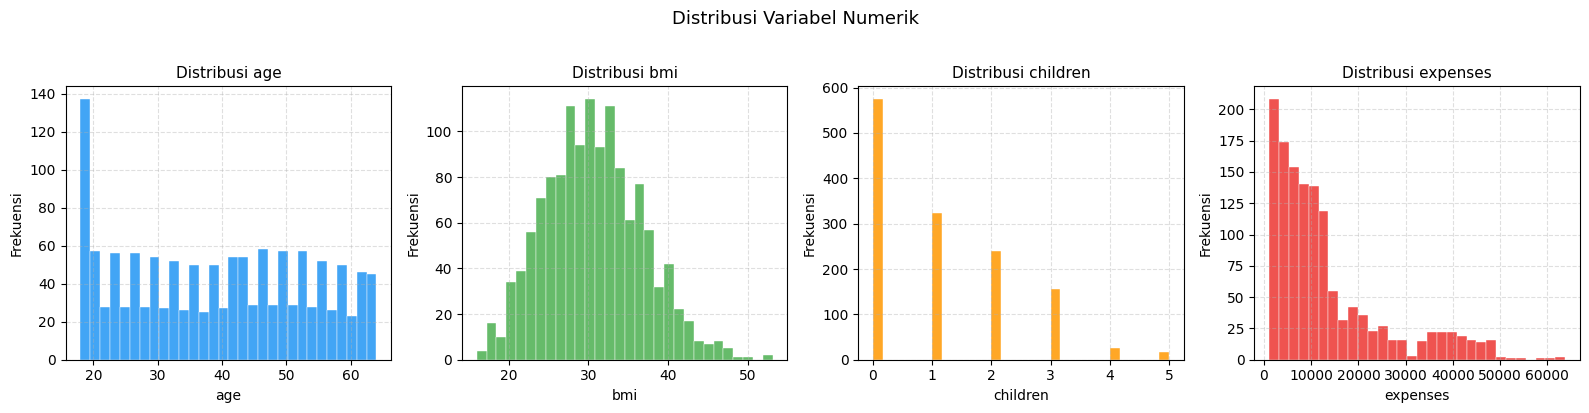

Plot disimpan ke artifacts/distribusi_numerik.png


In [7]:
# Visualisasi distribusi variabel numerik
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
num_cols  = ["age", "bmi", "children", "expenses"]
colors    = ["#42A5F5", "#66BB6A", "#FFA726", "#EF5350"]

for ax, col, color in zip(axes, num_cols, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor="white", linewidth=0.3)
    ax.set_title(f"Distribusi {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Frekuensi")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Variabel Numerik", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "distribusi_numerik.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot disimpan ke artifacts/distribusi_numerik.png")

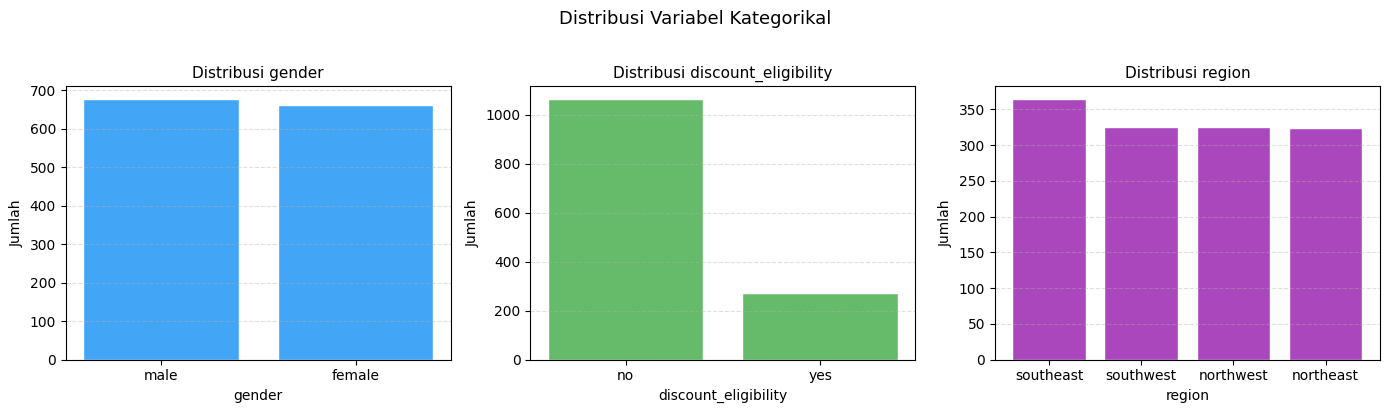

In [8]:
# Visualisasi distribusi variabel kategorikal
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cat_cols  = ["gender", "discount_eligibility", "region"]
colors    = ["#42A5F5", "#66BB6A", "#AB47BC"]

for ax, col, color in zip(axes, cat_cols, colors):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=color, edgecolor="white")
    ax.set_title(f"Distribusi {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Jumlah")
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.suptitle("Distribusi Variabel Kategorikal", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "distribusi_kategorikal.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Preprocessing Data

### 5.1 Encoding Variabel Kategorikal

Variabel kategorikal dikonversi menggunakan `LabelEncoder`:
- `gender` : `female=0`, `male=1`
- `discount_eligibility` : `no=0`, `yes=1`
- `region` : `northeast=0`, `northwest=1`, `southeast=2`, `southwest=3`

### 5.2 Scaling Variabel Numerik

Fitur numerik dinormalisasi menggunakan **Z-score (StandardScaler)**:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

Fitur yang di-scale: `age`, `bmi`, `children`.

In [9]:
def load_and_preprocess(filepath: str):
    """
    Memuat dataset asuransi, melakukan encoding pada variabel
    kategorikal, dan scaling pada variabel numerik.

    Parameters
    ----------
    filepath : str
        Path absolut/relatif menuju file CSV dataset.

    Returns
    -------
    states   : np.ndarray, shape (N, 6)  -- fitur profil pasien (scaled)
    expenses : np.ndarray, shape (N,)    -- biaya medis riil
    premiums : np.ndarray, shape (N,)    -- premi dasar
    scaler   : StandardScaler            -- objek scaler yang telah di-fit
    encoders : dict                      -- kamus LabelEncoder per kolom kategorikal
    """
    df = pd.read_csv(filepath)

    # --- Encoding Variabel Kategorikal ---
    categorical_cols = ["gender", "discount_eligibility", "region"]
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
        print(f"  Encoding '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # --- Scaling Variabel Numerik ---
    feature_cols = ["age", "gender", "bmi", "children", "discount_eligibility", "region"]
    numeric_cols = ["age", "bmi", "children"]

    scaler = StandardScaler()
    df_features = df[feature_cols].copy()
    df_features[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    states   = df_features.values.astype(np.float32)
    expenses = df["expenses"].values.astype(np.float32)
    premiums = df["premium"].values.astype(np.float32)

    return states, expenses, premiums, scaler, encoders


# Jalankan preprocessing
print("Melakukan preprocessing dataset...")
states, expenses, premiums, scaler, encoders = load_and_preprocess(DATASET_PATH)

print(f"\nHasil preprocessing:")
print(f"  states shape   : {states.shape}")
print(f"  expenses range : [{expenses.min():.2f}, {expenses.max():.2f}]")
print(f"  premiums range : [{premiums.min():.4f}, {premiums.max():.4f}]")
print(f"  state (baris 0): {states[0]}")

Melakukan preprocessing dataset...
  Encoding 'gender': {'female': 0, 'male': 1}
  Encoding 'discount_eligibility': {'no': 0, 'yes': 1}
  Encoding 'region': {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}

Hasil preprocessing:
  states shape   : (1338, 6)
  expenses range : [1121.87, 63770.43]
  premiums range : [11.2187, 1983.1064]
  state (baris 0): [-1.4387642  0.        -0.4536457 -0.9086137  1.         3.       ]


In [10]:
# Simpan data hasil preprocessing sebagai numpy array
# Data ini akan digunakan oleh notebook pelatihan dan evaluasi
np.save(os.path.join(ARTIFACT_DIR, "states.npy"),   states)
np.save(os.path.join(ARTIFACT_DIR, "expenses.npy"), expenses)
np.save(os.path.join(ARTIFACT_DIR, "premiums.npy"), premiums)

print("Data preprocessed disimpan ke folder artifacts/:")
print("  artifacts/states.npy")
print("  artifacts/expenses.npy")
print("  artifacts/premiums.npy")

Data preprocessed disimpan ke folder artifacts/:
  artifacts/states.npy
  artifacts/expenses.npy
  artifacts/premiums.npy


## 6. Definisi Custom Gymnasium Environment

### 6.1 Alasan Pemilihan Action Space Diskret (DQN)

| Kriteria | Penjelasan |
|----------|------------|
| Interpretabilitas | 5 tingkat harga lebih mudah dikomunikasikan kepada pemangku kepentingan bisnis |
| Kestabilan | DQN lebih stabil dibanding SAC/TD3 untuk masalah penetapan harga kategori terbatas |
| Transparansi | Q-value untuk 5 aksi dapat divisualisasikan dan diinterpretasikan |
| Praktis | Perusahaan asuransi umumnya menggunakan tier harga diskret |

### 6.2 Reward Function

$$\text{Proposed\_Premium} = \text{Base\_Premium} \times \text{Multiplier}(a)$$

$$\text{Profit} = \text{Proposed\_Premium} - \text{Actual\_Expenses}$$

$$\text{Penalty} = 2.0 \times \max\left(0,\ \text{Proposed\_Premium} - 1.5 \times \text{Actual\_Expenses}\right)$$

$$\text{Reward} = \text{clip}\left(\frac{\text{Profit} - \text{Penalty}}{1000},\ -10,\ 10\right)$$

In [11]:
class InsurancePricingEnv(gym.Env):
    """
    Custom Gymnasium Environment untuk Penetapan Harga Dinamis
    Asuransi Kesehatan.

    State   : Vektor profil demografis pasien (6 dimensi, sudah di-scale).
    Action  : Diskret 5 aksi -- pengali premi {0.8x, 0.9x, 1.0x, 1.1x, 1.2x}.
    Reward  : Profit bersih setelah dikurangi penalti harga tidak kompetitif.
    Episode : Satu penelusuran penuh dataset dari baris pertama hingga terakhir.
    """

    metadata = {"render_modes": ["human"]}

    # Daftar pengali aksi diskret
    ACTION_MULTIPLIERS = np.array([0.8, 0.9, 1.0, 1.1, 1.2], dtype=np.float32)

    def __init__(
        self,
        states: np.ndarray,
        expenses: np.ndarray,
        premiums: np.ndarray,
        penalty_threshold: float = 1.5,
        penalty_coef: float = 2.0,
    ):
        super().__init__()

        # Data pasien
        self.states    = states
        self.expenses  = expenses
        self.premiums  = premiums
        self.n_samples = len(states)

        # Parameter reward function
        self.penalty_threshold = penalty_threshold
        self.penalty_coef      = penalty_coef

        # Ruang Aksi: diskret, 5 pilihan
        self.action_space = spaces.Discrete(len(self.ACTION_MULTIPLIERS))

        # Ruang Observasi: vektor kontinu berdimensi 6
        obs_dim = states.shape[1]
        self.observation_space = spaces.Box(
            low  = -np.inf,
            high =  np.inf,
            shape = (obs_dim,),
            dtype = np.float32,
        )

        self._current_idx: int = 0
        self._last_info: dict  = {}

    def reset(self, seed=None, options=None):
        """
        Mereset environment ke baris pertama dataset.

        Returns
        -------
        observation : np.ndarray  -- profil pasien pertama
        info        : dict        -- kamus kosong
        """
        super().reset(seed=seed)
        self._current_idx = 0
        return self.states[self._current_idx], {}

    def step(self, action: int):
        """
        Mengeksekusi satu langkah:
        1. Hitung Proposed Premium = Base Premium x Multiplier(action).
        2. Hitung Profit = Proposed Premium - Actual Expenses.
        3. Terapkan penalti jika harga terlampau tinggi.
        4. Pindah ke baris berikutnya.

        Parameters
        ----------
        action : int  -- indeks aksi dalam {0, 1, 2, 3, 4}

        Returns
        -------
        observation : np.ndarray
        reward      : float
        terminated  : bool
        truncated   : bool
        info        : dict
        """
        idx = self._current_idx

        # Data pasien saat ini
        base_premium    = float(self.premiums[idx])
        actual_expenses = float(self.expenses[idx])

        # Proposed Premium = Base Premium x Multiplier
        multiplier       = float(self.ACTION_MULTIPLIERS[action])
        proposed_premium = base_premium * multiplier

        # Profit Dasar
        profit = proposed_premium - actual_expenses

        # Penalti harga tidak kompetitif
        excess  = proposed_premium - self.penalty_threshold * actual_expenses
        penalty = self.penalty_coef * max(0.0, excess)

        # Reward akhir (ternormalisasi)
        reward = float(np.clip((profit - penalty) / 1000.0, -10.0, 10.0))

        self._last_info = {
            "index"           : idx,
            "base_premium"    : base_premium,
            "multiplier"      : multiplier,
            "proposed_premium": proposed_premium,
            "actual_expenses" : actual_expenses,
            "profit"          : profit,
            "penalty"         : penalty,
            "raw_reward"      : profit - penalty,
        }

        self._current_idx += 1
        terminated = self._current_idx >= self.n_samples
        observation = self.states[idx] if terminated else self.states[self._current_idx]

        return observation, reward, terminated, False, self._last_info

    def render(self):
        """Menampilkan informasi langkah terakhir ke konsol."""
        info = self._last_info
        if not info:
            print("Environment belum dijalankan.")
            return
        print(
            f"[Step {info['index']:4d}] "
            f"Multiplier: {info['multiplier']:.1f}x | "
            f"Proposed: {info['proposed_premium']:8.2f} | "
            f"Expenses: {info['actual_expenses']:8.2f} | "
            f"Profit: {info['profit']:8.2f} | "
            f"Penalty: {info['penalty']:6.2f}"
        )

    def close(self):
        pass


print("Kelas InsurancePricingEnv berhasil didefinisikan.")

Kelas InsurancePricingEnv berhasil didefinisikan.


## 7. Validasi Environment

In [12]:
# Membuat instance environment
env = InsurancePricingEnv(
    states           = states,
    expenses         = expenses,
    premiums         = premiums,
    penalty_threshold = 1.5,
    penalty_coef     = 2.0,
)

print("Informasi Environment:")
print(f"  Action space       : {env.action_space}")
print(f"  Observation space  : {env.observation_space}")
print(f"  Jumlah sampel      : {env.n_samples}")
print(f"  Action multipliers : {env.ACTION_MULTIPLIERS}")
print()

# Validasi menggunakan Gymnasium checker
print("Menjalankan check_env()...")
check_env(env, warn=True)
print("Validasi LULUS.")

Informasi Environment:
  Action space       : Discrete(5)
  Observation space  : Box(-inf, inf, (6,), float32)
  Jumlah sampel      : 1338
  Action multipliers : [0.8 0.9 1.  1.1 1.2]

Menjalankan check_env()...
Validasi LULUS.


In [13]:
# Uji manual: menjalankan 5 langkah pertama dengan aksi acak
print("Uji manual (5 langkah pertama):")
print(f"{'Step':>4} | {'Aksi':>4} | {'Multiplier':>10} | {'Proposed':>10} | {'Expenses':>10} | {'Profit':>10} | {'Reward':>8}")
print("-" * 70)

obs, _ = env.reset()
for step in range(5):
    action = env.action_space.sample()           # Aksi acak
    obs, reward, terminated, truncated, info = env.step(action)
    print(
        f"{info['index']:>4} | "
        f"{action:>4} | "
        f"{info['multiplier']:>10.1f} | "
        f"{info['proposed_premium']:>10.2f} | "
        f"{info['actual_expenses']:>10.2f} | "
        f"{info['profit']:>10.2f} | "
        f"{reward:>8.4f}"
    )
    if terminated:
        break

Uji manual (5 langkah pertama):
Step | Aksi | Multiplier |   Proposed |   Expenses |     Profit |   Reward
----------------------------------------------------------------------
   0 |    2 |        1.0 |     168.85 |   16884.92 |  -16716.07 | -10.0000
   1 |    4 |        1.2 |      20.71 |    1725.55 |   -1704.84 |  -1.7048
   2 |    1 |        0.9 |      40.05 |    4449.46 |   -4409.41 |  -4.4094
   3 |    2 |        1.0 |     439.69 |   21984.47 |  -21544.78 | -10.0000
   4 |    4 |        1.2 |      92.80 |    3866.86 |   -3774.06 |  -3.7741


## 8. Tabel Referensi Action Space

Berikut adalah tabel lengkap mapping aksi diskret ke pengali premi:

In [14]:
action_df = pd.DataFrame({
    "Indeks Aksi"        : [0, 1, 2, 3, 4],
    "Pengali (x)"        : [0.8, 0.9, 1.0, 1.1, 1.2],
    "Persentase Perubahan": ["-20%", "-10%", "0% (standar)", "+10%", "+20%"],
    "Interpretasi Bisnis" : [
        "Diskon besar -- menarik pelanggan berisiko rendah",
        "Diskon kecil -- sedikit di bawah harga pasar",
        "Harga standar -- tidak ada penyesuaian",
        "Kenaikan kecil -- sedikit di atas harga pasar",
        "Kenaikan besar -- untuk profil risiko tinggi",
    ],
})

print("Tabel Action Space:")
print(action_df.to_string(index=False))

Tabel Action Space:
 Indeks Aksi  Pengali (x) Persentase Perubahan                               Interpretasi Bisnis
           0          0.8                 -20% Diskon besar -- menarik pelanggan berisiko rendah
           1          0.9                 -10%      Diskon kecil -- sedikit di bawah harga pasar
           2          1.0         0% (standar)            Harga standar -- tidak ada penyesuaian
           3          1.1                 +10%     Kenaikan kecil -- sedikit di atas harga pasar
           4          1.2                 +20%      Kenaikan besar -- untuk profil risiko tinggi


## 9. Ringkasan

Notebook ini telah menyelesaikan:

1. Memuat dataset `medical_insurance.csv` (1.338 baris, 8 kolom).
2. Encoding variabel kategorikal (`gender`, `discount_eligibility`, `region`).
3. Scaling variabel numerik (`age`, `bmi`, `children`) dengan StandardScaler.
4. Mendefinisikan `InsurancePricingEnv` sebagai custom `gymnasium.Env`.
5. Memvalidasi environment dengan `check_env` (LULUS).
6. Menyimpan data preprocessed ke folder `artifacts/` untuk digunakan notebook berikutnya.

**Langkah Berikutnya**: Jalankan `02_pelatihan_dqn.ipynb` untuk melatih agen DQN.